<a href="https://colab.research.google.com/github/Bonrice/Google-Colab-Projects/blob/main/Steam_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pyspark.sql import SparkSession

# Increase Spark driver memory to prevent OutOfMemory errors
spark = SparkSession.builder.master("local[*]").config("spark.driver.memory", "16g").getOrCreate()
print("SparkSession created successfully.")
spark

SparkSession created successfully.


In [3]:
from pyspark.sql.functions import col, try_to_timestamp, lit

# Reload reviews DataFrame to ensure it's in the expected state
reviews = spark.read.csv('/content/drive/MyDrive/steam_dataset/reviews.csv', header=True)

# Apply the timestamp conversion to new columns
reviews = reviews.withColumn("review_updated_at", try_to_timestamp(col("updated_at"), lit("yyyy-MM-dd HH:mm:ss.SSSSSSXXX"))) \
.withColumn('review_created_at', try_to_timestamp(col('created_at'), lit('yyyy-MM-dd HH:mm:ss.SSSSSSXXX')))

from IPython.core import application
from pyspark.sql.functions import col, try_to_timestamp, lit

# Reload reviews DataFrame to ensure it's in the expected state
application = spark.read.csv('/content/drive/MyDrive/steam_dataset/applications.csv', header=True)

# Apply the timestamp conversion to new columns
application = application.withColumn("application_updated_at", try_to_timestamp(col("updated_at"), lit("yyyy-MM-dd HH:mm:ss.SSSSSSXXX"))) \
.withColumn('application_created_at', try_to_timestamp(col('created_at'), lit('yyyy-MM-dd HH:mm:ss.SSSSSSXXX')))

In [4]:
merged_df = application.join(reviews, on='appid', how='left')

from pyspark.sql.functions import to_timestamp, col, lit, try_to_timestamp
from pyspark.sql.types import BooleanType, IntegerType, DoubleType, LongType

steam = merged_df.withColumn('author_num_games_owned', col('author_num_games_owned').cast(IntegerType())) \
          .withColumn('author_num_reviews', col('author_num_reviews').cast(DoubleType())) \
          .withColumn('author_playtime_forever', col('author_playtime_forever').cast(DoubleType())) \
          .withColumn('author_playtime_last_two_weeks', col('author_playtime_last_two_weeks').cast(DoubleType())) \
          .withColumn('author_playtime_at_review', col('author_playtime_at_review').cast(DoubleType())) \
          .withColumn('timestamp_created', try_to_timestamp(col('timestamp_created'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('timestamp_updated', try_to_timestamp(col('timestamp_updated'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('weighted_vote_score', col('weighted_vote_score').cast(DoubleType())) \
          .withColumn('comment_count', col('comment_count').cast(DoubleType())) \
          .withColumn('steam_purchase', col('steam_purchase').cast(BooleanType())) \
          .withColumn('received_for_free', col('received_for_free').cast(BooleanType())) \
          .withColumn('written_during_early_access', col('written_during_early_access').cast(BooleanType())) \
          .withColumn('is_free', col('is_free').cast(BooleanType())) \
          .withColumn('release_date', try_to_timestamp(col('release_date'), lit('yyyy-MM-dd HH:mm:ss'))) \
          .withColumn('required_age', col('required_age').cast(DoubleType())) \
          .withColumn('metacritic_score', col('metacritic_score').cast(DoubleType())) \
          .withColumn('recommendations_total', col('recommendations_total').cast(DoubleType())) \
          .withColumn('mat_supports_windows', col('mat_supports_windows').cast(BooleanType())) \
          .withColumn('mat_supports_mac', col('mat_supports_mac').cast(BooleanType())) \
          .withColumn('mat_supports_linux', col('mat_supports_linux').cast(BooleanType())) \
          .withColumn('mat_initial_price', col('mat_initial_price').cast(DoubleType())) \
          .withColumn('mat_final_price', col('mat_final_price').cast(DoubleType())) \
          .withColumn('mat_discount_percent', col('mat_discount_percent').cast(DoubleType())) \
          .withColumn('mat_achievement_count', col('mat_achievement_count').cast(DoubleType())) \

print('Schema:')
steam.printSchema()

Schema:
root
 |-- appid: string (nullable = true)
 |-- name: string (nullable = true)
 |-- type: string (nullable = true)
 |-- is_free: boolean (nullable = true)
 |-- release_date: timestamp (nullable = true)
 |-- required_age: double (nullable = true)
 |-- short_description: string (nullable = true)
 |-- supported_languages: string (nullable = true)
 |-- header_image: string (nullable = true)
 |-- background: string (nullable = true)
 |-- metacritic_score: double (nullable = true)
 |-- recommendations_total: double (nullable = true)
 |-- mat_supports_windows: boolean (nullable = true)
 |-- mat_supports_mac: boolean (nullable = true)
 |-- mat_supports_linux: boolean (nullable = true)
 |-- mat_initial_price: double (nullable = true)
 |-- mat_final_price: double (nullable = true)
 |-- mat_discount_percent: double (nullable = true)
 |-- mat_currency: string (nullable = true)
 |-- mat_achievement_count: double (nullable = true)
 |-- mat_pc_os_min: string (nullable = true)
 |-- mat_pc_proce

In [5]:
steam = steam.drop('header_image','background','mat_pc_os_min','mat_pc_processor_min','mat_pc_memory_min','mat_pc_graphics_min','mat_pc_os_rec','mat_pc_processor_rec','mat_pc_memory_rec','mat_pc_graphics_rec','created_at','updated_at')

In [6]:
from pyspark.sql.functions import col, lower
from pyspark.sql import functions as F

english = steam.filter(lower(col('language')).contains('english'))
english_bools = english.filter(F.col("voted_up").try_cast("boolean").isNotNull())

In [7]:
training = english_bools.select('appid','name','author_steamid','review_text','voted_up')

from pyspark.sql.functions import col, when

training_binary = training.withColumn(
    "label",
    when(col("voted_up") == True, 1)
    .when(col("voted_up") == False, 0)
    .otherwise(None)  # Preserve nulls
)
#training_binary.show()

In [8]:
import pyspark.sql.functions as F

# Train/Test Split using PySpark's randomSplit
train_steam, test_steam = training_binary.randomSplit([0.8, 0.2], seed=42)

print(f"Number of rows in train_steam: {train_steam.count()}")
print(f"Number of columns in train_steam: {len(train_steam.columns)}")
print(f"Number of rows in test_steam: {test_steam.count()}")
print(f"Number of columns in test_steam: {len(test_steam.columns)}")

Number of rows in train_steam: 271360
Number of columns in train_steam: 6
Number of rows in test_steam: 67797
Number of columns in test_steam: 6


In [9]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import HashingTF, Tokenizer, IDF

# Configure an ML pipeline, which consists of three stages: tokenizer, hashingTF, and lr.
tokenizer = Tokenizer(inputCol="review_text", outputCol="words")
hashingTF = HashingTF(inputCol=tokenizer.getOutputCol(), outputCol="rawfeatures")
lr = LogisticRegression(maxIter=10, regParam=0.001, labelCol="label")
idf = IDF(inputCol=hashingTF.getOutputCol(), outputCol="features")
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, lr])

# Fill nulls in 'review_text' with empty strings before fitting
train_steam_cleaned = train_steam.na.fill('', subset=['review_text'])

# Fit the pipeline to training documents.
model = pipeline.fit(train_steam_cleaned)

In [ ]:
import pyspark.sql.functions as F

# Ensure 'review_text' has no nulls by explicitly replacing with empty string
test_steam_cleaned = test_steam.withColumn(
    'review_text', F.coalesce(F.col('review_text'), F.lit(''))
)

# Ensure 'label' has no nulls, as LogisticRegression requires a valid label.
# Null labels would cause issues during evaluation or even during model transformation.
test_steam_cleaned = test_steam_cleaned.filter(F.col('label').isNotNull())

# Cache the cleaned DataFrame to materialize changes before transformation
test_steam_cleaned.cache()

prediction = model.transform(test_steam_cleaned)

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Force evaluation of predictions
prediction.cache()  # Keep in memory for repeated use
prediction.show(5, truncate=False)  # Show sample predictions to confirm

# Create evaluator
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# Compute ROC AUC
roc_auc = evaluator.evaluate(prediction)

# Safely extract LogisticRegressionModel from pipeline
from pyspark.ml.classification import LogisticRegressionModel

# Find the LR model stage dynamically
lrmodel = None
for stage in model.stages:
    if isinstance(stage, LogisticRegressionModel):
        lrmodel = stage
        break

if lrmodel is None:
    raise ValueError("No LogisticRegressionModel found in pipeline stages.")

# Print results immediately
print("Coefficients:", lrmodel.coefficients)
print("Intercept:", lrmodel.intercept)
print("Area Under ROC:", roc_auc)

# Force flush stdout
import sys
sys.stdout.flush()

+-------+--------------------------------+-----------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

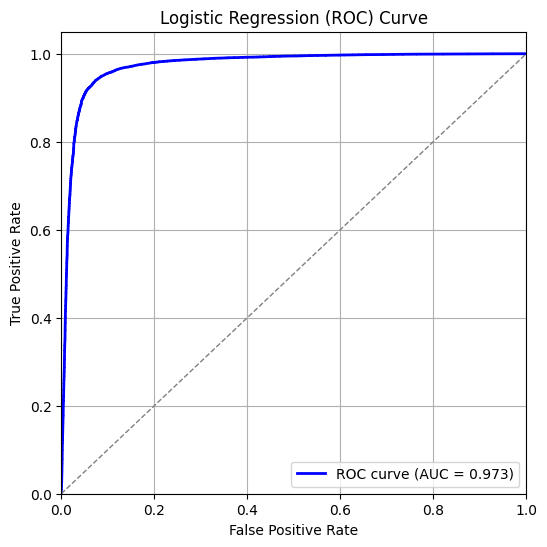

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Step 1: Extract probability and label columns
# probability is a Vector, so we take the probability of class 1
preds = prediction.select("label", "probability").rdd.map(lambda row: (float(row.label), float(row.probability[1])))

# Step 2: Convert to Pandas for sklearn
preds_df = preds.toDF(["label", "probability"]).toPandas()

# Step 3: Compute ROC curve and AUC using sklearn
fpr, tpr, thresholds = roc_curve(preds_df["label"], preds_df["probability"])
roc_auc = auc(fpr, tpr)

# Step 4: Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from pyspark.sql.functions import col

# Count correct predictions
correct_preds = prediction.filter(col("label") == col("prediction")).count()

# Count total predictions
total_preds = prediction.count()

# Calculate accuracy
accuracy = correct_preds / total_preds if total_preds > 0 else 0

print(f"Correct Predictions: {correct_preds}")
print(f"Total Predictions: {total_preds}")
print(f"Accuracy: {accuracy:.4f}")

Correct Predictions: 63839
Total Predictions: 67556
Accuracy: 0.9450


In [ ]:
# Fill nulls in 'review_text' with empty strings before fitting
train_steam_cleaned = train_steam.na.fill('', subset=['review_text'])

fractions = train_steam_cleaned.select("label").distinct().withColumn("fraction", lit(0.1)).rdd.collectAsMap()
steam_sample = train_steam_cleaned.stat.sampleBy("label", fractions, seed=42)

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, floor
import math


# Step 1: Count total rows and target sample size
total_count = train_steam_cleaned.count()
target_count = math.floor(total_count * 0.1)  # exactly 10%

# Step 2: Count rows per label
label_counts = train_steam_cleaned.groupBy("label").count()

# Step 3: Compute per-label sample sizes proportional to their share
label_sample_sizes = (
    label_counts
    .withColumn("sample_size", floor(col("count") / total_count * target_count))
)

# Step 4: Join back and assign a random number to each row
from pyspark.sql.functions import rand

df_with_rand = train_steam_cleaned.join(label_sample_sizes.select("label", "sample_size"), on="label") \
                 .withColumn("rand", rand(seed=42))

# Step 5: Take the top N rows per label based on random number
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

w = Window.partitionBy("label").orderBy("rand")

sampled_df = (
    df_with_rand
    .withColumn("rn", row_number().over(w))
    .filter(col("rn") <= col("sample_size"))
    .drop("rand", "rn", "sample_size")
)

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import HashingTF, Tokenizer, IDF

# Configure an ML pipeline, which consists of three stages: tokenizer, hashingTF, and lr.
tokenizer = Tokenizer(inputCol="review_text", outputCol="words")
hashingTF = HashingTF(inputCol=tokenizer.getOutputCol(), outputCol="rawfeatures")
lr = LogisticRegression(maxIter=10, regParam=0.001, labelCol="label")
idf = IDF(inputCol=hashingTF.getOutputCol(), outputCol="features")
pipeline = Pipeline(stages=[tokenizer, hashingTF, idf, lr])



# Fit the pipeline to training documents.
model = pipeline.fit(sampled_df)

In [ ]:
from pyspark.sql.functions import col

# Count correct predictions
correct_preds = prediction.filter(col("label") == col("prediction")).count()

# Count total predictions
total_preds = prediction.count()

# Calculate accuracy
accuracy = correct_preds / total_preds if total_preds > 0 else 0

print(f"Correct Predictions: {correct_preds}")
print(f"Total Predictions: {total_preds}")
print(f"Accuracy: {accuracy:.4f}")

Correct Predictions: 58475
Total Predictions: 67556
Accuracy: 0.8656


In [11]:
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

train_steam_cleaned.cache()
# Re-define lr for cross-validation without initial regParam or elasticNetParam values
lr_cv = LogisticRegression(labelCol="label")

# Create a new pipeline that includes all feature transformations and the new LR model
# Reuse tokenizer, hashingTF, idf defined in cell viW9-c5AaWFl
pipeline_cv = Pipeline(stages=[tokenizer, hashingTF, idf, lr_cv])

paramGrid = ParamGridBuilder() \
    .addGrid(lr_cv.regParam, [0.01, 0.001]) \
    .addGrid(lr_cv.elasticNetParam, [0.0, 0.5]) \
    .addGrid(lr.maxIter, [10, 20]) \
    .build()


# TrainValidationSplit with trainRatio=1.0 to skip actual CV
tvs = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(labelCol="label"),
    trainRatio=1.0  # effectively no separate validation set
)

# Fit model (grid search will still explore all hyperparameter combos)
model = tvs.fit(train_steam_cleaned)


In [20]:
from pyspark.ml.classification import LogisticRegression, LogisticRegressionModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pyspark.sql.functions as F

bestModel = model.bestModel # This will be a PipelineModel

print("Best Model Parameters:")
# Find the LogisticRegressionModel within the best PipelineModel stages
best_lr_model = None
for stage in bestModel.stages:
    if isinstance(stage, LogisticRegressionModel):
        best_lr_model = stage
        break

if best_lr_model is None:
    raise ValueError("LogisticRegressionModel not found in best PipelineModel stages.")

# Now, we can access the parameters from the best_lr_model
print(f"  - regParam: {best_lr_model.getRegParam()}") # Use getter methods
print(f"  - elasticNetParam: {best_lr_model.getElasticNetParam()}") # Use getter methods
print(f"  - maxIter: {best_lr_model.getMaxIter()}") # Use getter methods

# Initialize evaluator in the current scope
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Ensure 'review_text' has no nulls by explicitly replacing with empty string
test_steam_cleaned = test_steam.withColumn(
    'review_text', F.coalesce(F.col('review_text'), F.lit(''))
)
# Ensure 'label' has no nulls, as LogisticRegression requires a valid label.
# Null labels would cause issues during evaluation or even during model transformation.
test_steam_cleaned = test_steam_cleaned.filter(F.col('label').isNotNull())
# Cache the cleaned DataFrame to materialize changes before transformation
test_steam_cleaned.cache()

auc = evaluator.evaluate(bestModel.transform(test_steam_cleaned))
print(f"Best Model AUC: {auc:.4f}")

Best Model Parameters:
  - regParam: 0.001
  - elasticNetParam: 0.0
  - maxIter: 10


Py4JError: An error occurred while calling None.org.apache.spark.ml.evaluation.BinaryClassificationEvaluator$getActiveSession

In [ ]:
test_steam_cleaned = test_steam.withColumn(
    'review_text', F.coalesce(F.col('review_text'), F.lit(''))
)

# Ensure 'label' has no nulls, as LogisticRegression requires a valid label.
# Null labels would cause issues during evaluation or even during model transformation.
test_steam_cleaned = test_steam_cleaned.filter(F.col('label').isNotNull())

# Cache the cleaned DataFrame to materialize changes before transformation
test_steam_cleaned.cache()

prediction = model.transform(test_steam_cleaned)

In [ ]:
from pyspark.sql.functions import col

# Count correct predictions
correct_preds = prediction.filter(col("label") == col("prediction")).count()

# Count total predictions
total_preds = prediction.count()

# Calculate accuracy
accuracy = correct_preds / total_preds if total_preds > 0 else 0

print(f"Correct Predictions: {correct_preds}")
print(f"Total Predictions: {total_preds}")
print(f"Accuracy: {accuracy:.4f}")

Correct Predictions: 58475
Total Predictions: 67556
Accuracy: 0.8656


In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression

train_steam_cleaned.cache()
# Re-define lr for cross-validation without initial regParam or elasticNetParam values
lr_cv = LogisticRegression(labelCol="label")

# Create a new pipeline that includes all feature transformations and the new LR model
# Reuse tokenizer, hashingTF, idf defined in cell viW9-c5AaWFl
pipeline_cv = Pipeline(stages=[tokenizer, hashingTF, idf, lr_cv])

paramGrid = ParamGridBuilder() \
    .addGrid(lr_cv.regParam, [0.001]) \
    .addGrid(lr_cv.elasticNetParam, [0.5]) \
    .build()

crossval = CrossValidator(
    estimator=pipeline_cv, # Use the new pipeline as the estimator
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=2,            # 3-fold cross-validation
    parallelism=2          # Run folds in parallel
)

# ---------------------------
# 8. Fit Model with Cross-Validation
# ---------------------------
cvModel = crossval.fit(train_steam_cleaned)

# ---------------------------
# 9. Get Best Model & Metrics
# ---------------------------
bestModel = cvModel.bestModel # This will be a PipelineModel

print("Best Model Parameters:")
# Find the LogisticRegressionModel within the best PipelineModel stages
best_lr_model = None
for stage in bestModel.stages:
    if isinstance(stage, LogisticRegressionModel):
        best_lr_model = stage
        break

if best_lr_model is None:
    raise ValueError("LogisticRegressionModel not found in best PipelineModel stages.")

# Now, we can access the parameters from the best_lr_model
print(f"  - regParam: {best_lr_model.getRegParam()}") # Use getter methods
print(f"  - elasticNetParam: {best_lr_model.getElasticNetParam()}") # Use getter methods

auc = evaluator.evaluate(bestModel.transform(test_steam_cleaned))
print(f"Best Model AUC: {auc:.4f}")

Best Model Parameters:
  - regParam: 0.001
  - elasticNetParam: 0.5
Best Model AUC: 0.9329


In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression

# Re-define lr for cross-validation without initial regParam or elasticNetParam values
lr_cv = LogisticRegression(labelCol="label")

# Create a new pipeline that includes all feature transformations and the new LR model
# Reuse tokenizer, hashingTF, idf defined in cell viW9-c5AaWFl
pipeline_cv = Pipeline(stages=[tokenizer, hashingTF, idf, lr_cv])

paramGrid = ParamGridBuilder() \
    .addGrid(lr_cv.regParam, [0.01, 0.1, 1.0]) \
    .addGrid(lr_cv.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

crossval = CrossValidator(
    estimator=pipeline_cv, # Use the new pipeline as the estimator
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,            # 3-fold cross-validation
    parallelism=2          # Run folds in parallel
)

# ---------------------------
# 8. Fit Model with Cross-Validation
# ---------------------------
cvModel = crossval.fit(train_steam_cleaned)

# ---------------------------
# 9. Get Best Model & Metrics
# ---------------------------
bestModel = cvModel.bestModel # This will be a PipelineModel

print("Best Model Parameters:")
# Find the LogisticRegressionModel within the best PipelineModel stages
best_lr_model = None
for stage in bestModel.stages:
    if isinstance(stage, LogisticRegressionModel):
        best_lr_model = stage
        break

if best_lr_model is None:
    raise ValueError("LogisticRegressionModel not found in best PipelineModel stages.")

# Now, we can access the parameters from the best_lr_model
print(f"  - regParam: {best_lr_model.getRegParam()}") # Use getter methods
print(f"  - elasticNetParam: {best_lr_model.getElasticNetParam()}") # Use getter methods

auc = evaluator.evaluate(bestModel.transform(test_steam_cleaned))
print(f"Best Model AUC: {auc:.4f}")

KeyboardInterrupt: 

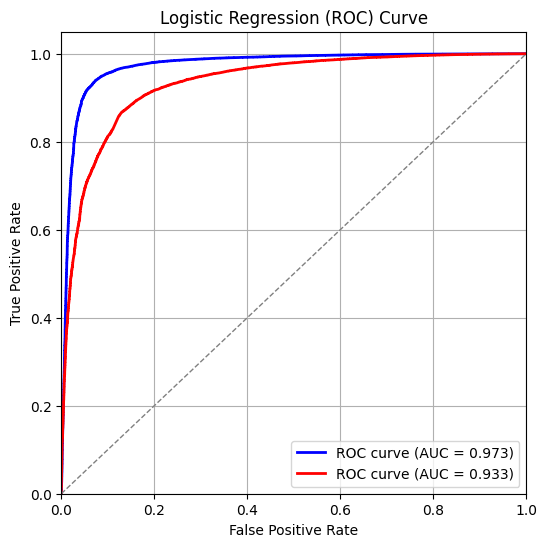

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

tuned_predicition = bestModel.transform(test_steam_cleaned)

preds_t = tuned_predicition.select("label", "probability").rdd.map(lambda row: (float(row.label), float(row.probability[1])))
preds_df_t = preds_t.toDF(["label", "probability"]).toPandas()

# Step 3: Compute ROC curve and AUC using sklearn
fpr_t, tpr_t, thresholds_t = roc_curve(preds_df_t["label"], preds_df_t["probability"])
roc_auc_t = auc(fpr_t, tpr_t)

# Step 4: Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"Default Parameters (AUC = {roc_auc:.3f})")
plt.plot(fpr_t, tpr_t, color="red", lw=2, label=f"Fine Tuning (AUC = {roc_auc_t:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluators for metrics
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

# Calculate metrics
precision = precision_evaluator.evaluate(prediction)
recall = recall_evaluator.evaluate(prediction)
f1_score = f1_evaluator.evaluate(prediction)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")


Precision: 0.9444
Recall:    0.9450
F1 Score:  0.9446
